# Polyfit

Let's return to our polynomial fitting armed with our new tool, and use it to separate the order of the polynomial from the number of data points.

An $n$ th degree polynomial,

$$ y(x) = a_n x^n + a_{n-1} x^{n-1} \dots a_2 x^2 + a_1 x +a_0$$

can be applied to $m$ data points,

$y(x_i) = a_n x_i^n + a_{n-1} x_i^{n-1} \dots a_2 x_i^2 + a_1 x_i +a_0 = y_i$

to generate an $m \times n$ matrix, multiplied by an $n$ vector of polynomial coefficients to equal an $m$ vector of data:

$$
 \begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^n \\
1 & x_2 & x_2^2 & \cdots & x_2^n \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_m & x_m^2 & \cdots & x_m^n
\end{bmatrix}
\begin{bmatrix}
a_0 \\
a_1 \\
a_2 \\
\vdots \\
a_n
\end{bmatrix} =
\begin{bmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_m
\end{bmatrix}
$$

#### Example: Determine the coefficients of a cubic polynomial

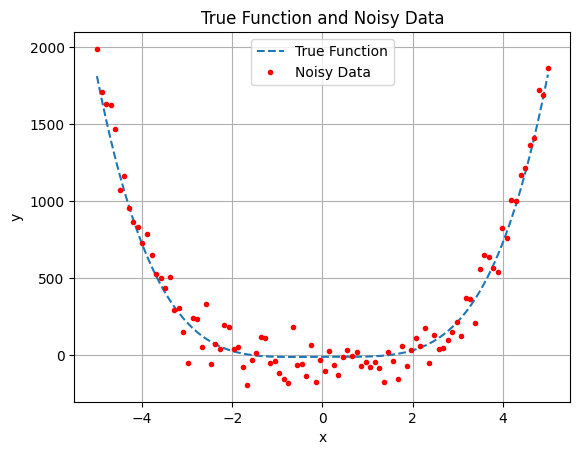

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x values
x = np.linspace(-5, 5, 100)

# Define the true function
def true_function(x):
  return 3 * x**4 - 2 * x**2 + x - 9

# Calculate the true y values
y_true = true_function(x)

# Generate noisy data
np.random.seed(0)  # For reproducibility
noise = np.random.normal(0, 100, 100)
x_data = np.linspace(-5, 5, 100)
y_data = true_function(x_data) + noise

# Plot the true curve and the data
plt.plot(x, y_true, '--', label='True Function')
plt.plot(x_data, y_data, 'ro', markersize=3, label='Noisy Data')

plt.xlabel('x')
plt.ylabel('y')
plt.title('True Function and Noisy Data')
plt.legend()
plt.grid(True)
plt.show()


Coefficients calculated manually [ 6.28230705e-02  6.87425501e+01 -2.93452380e+00 -2.14197455e+02] 

Coefficients calculated with polyfit [ 6.28230705e-02  6.87425501e+01 -2.93452380e+00 -2.14197455e+02]


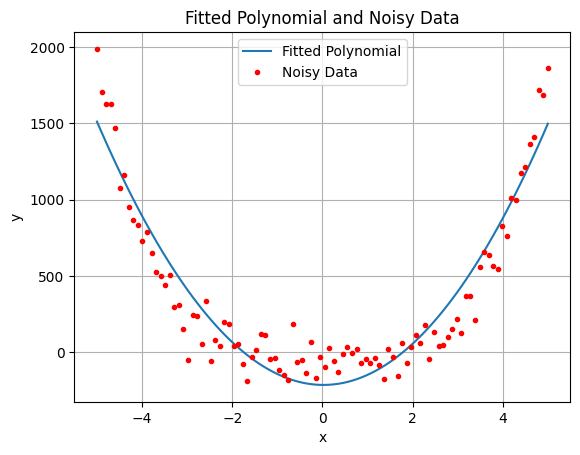

In [2]:
import matplotlib.pyplot as plt
import numpy as np
# Generate the Vandermonde matrix for a cubic polynomial
n = 3  # Degree of the polynomial
X = np.vander(x_data, n + 1)

# Calculate the coefficients using the pseudoinverse
coefficients = np.linalg.pinv(X) @ y_data

coeffs = np.polyfit(x_data, y_data, 3)
print('Coefficients calculated manually', coefficients, '\n')
print('Coefficients calculated with polyfit', coeffs)

# Generate y values for the fitted polynomial
fitted_polynomial = np.poly1d(coeffs)
y_fitted = fitted_polynomial(x)


# Plot the fitted polynomial along with the data
plt.plot(x, y_fitted, label='Fitted Polynomial')
plt.plot(x_data, y_data, 'ro', markersize=3, label='Noisy Data')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Fitted Polynomial and Noisy Data')
plt.legend()
plt.grid(True)
plt.show()


#### Example 2: Find a series of 'best fit polynomials'

Degree 0: Residual Norm = 5515.03, Coefficients = [np.float64(370.23)]
Degree 1: Residual Norm = 5514.73, Coefficients = [np.float64(-1.97), np.float64(370.23)]
Degree 2: Residual Norm = 1759.53, Coefficients = [np.float64(68.74), np.float64(-1.97), np.float64(-214.2)]
Degree 3: Residual Norm = 1759.49, Coefficients = [np.float64(0.06), np.float64(68.74), np.float64(-2.93), np.float64(-214.2)]
Degree 4: Residual Norm = 923.52, Coefficients = [np.float64(3.03), np.float64(0.06), np.float64(2.62), np.float64(-2.93), np.float64(-45.63)]
Degree 5: Residual Norm = 917.81, Coefficients = [np.float64(-0.08), np.float64(3.03), np.float64(2.38), np.float64(2.62), np.float64(-15.58), np.float64(-45.63)]
Degree 6: Residual Norm = 917.57, Coefficients = [np.float64(0.01), np.float64(-0.08), np.float64(2.8), np.float64(2.38), np.float64(4.56), np.float64(-15.58), np.float64(-47.98)]
Degree 7: Residual Norm = 916.86, Coefficients = [np.float64(-0.0), np.float64(0.01), np.float64(0.1), np.float64(2.8

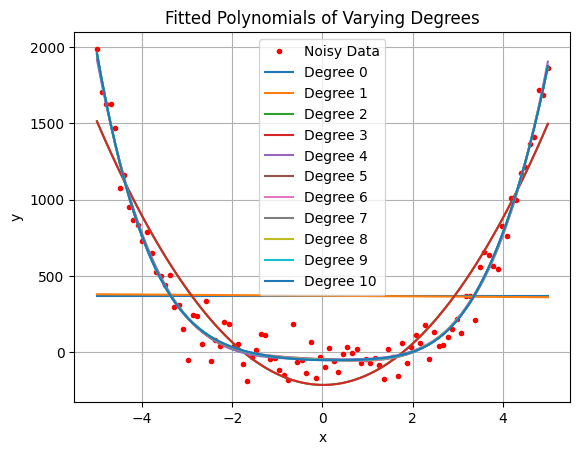

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x values
x = np.linspace(-5, 5, 100)

# Define the true function
def true_function(x):
  return 3 * x**4 - 2 * x**2 + x - 9

# Generate noisy data
np.random.seed(0)  # For reproducibility
noise = np.random.normal(0, 100, 100)
x_data = np.linspace(-5, 5, 100)
y_data = true_function(x_data) + noise

# Plot the true curve and the data
plt.plot(x_data, y_data, 'ro', markersize=3, label='Noisy Data')

for degree in range(11):
    coeffs = np.polyfit(x_data, y_data, degree)
    fitted_polynomial = np.poly1d(coeffs)
    y_fitted = fitted_polynomial(x)
    plt.plot(x, y_fitted, label=f'Degree {degree}')
    residuals = y_data - fitted_polynomial(x_data)
    residual_norm = np.linalg.norm(residuals)
    print(f"Degree {degree}: Residual Norm = {residual_norm:.2f}, Coefficients = {[round(c, 2) for c in coeffs]}")

plt.xlabel('x')
plt.ylabel('y')
plt.title('Fitted Polynomials of Varying Degrees')
plt.legend()
plt.grid(True)
plt.show()


Interesting points: The curve actually is 4th order but because additional terms will always reduce the error, it is not trivial to tell which is the *best*, best fit!

#### Example 3: Consider the condition number of the Vermonde matrix for increasing n

In [4]:
import numpy as np
# Generate x values
x_data = np.linspace(-5, 5, 10)

for degree in range(1, 11):
    # Generate the Vandermonde matrix for a given degree
    X = np.vander(x_data, degree + 1)

    # Calculate the condition number
    condition_number = np.linalg.cond(X)

    print(f"Degree {degree}: Condition Number = {condition_number:.2f}")


Degree 1: Condition Number = 3.19
Degree 2: Condition Number = 20.60
Degree 3: Condition Number = 94.89
Degree 4: Condition Number = 583.63
Degree 5: Condition Number = 2841.25
Degree 6: Condition Number = 17743.56
Degree 7: Condition Number = 95457.72
Degree 8: Condition Number = 648343.57
Degree 9: Condition Number = 5082996.99
Degree 10: Condition Number = 25360712.21


Recall that as the condition number strays from 1, numerical algorithms deteriorate. This is why low-order polynomials are more numerically robust to fit than high order!